# Seemingly Unrelated Regression (SUR) Models


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arviz import convert_to_inference_data, summary
import scipy.linalg as la
import scipy.stats as st
from IPython.display import display
from seaborn import heatmap
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def gibbs_sur(y, Z, n, hyper_param, burnin=1000, draws=10000, equation_id=None, rng=None):
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    nt, nk = Z.shape
    t = nt // n
    k = nk // n
    b0, A0, nu0, Lam0 = hyper_param
    b_ols = la.solve(Z.T @ Z, Z.T @ y)
    E = (y - Z @ b_ols).reshape((n, t))
    Sigma = (E @ E.T) / t
    nu_star = t + nu0
    A0b0 = A0 @ b0
    runs = np.empty((iterations, nk + n * n))
    for it in trange(iterations):
        Omega = np.kron(la.inv(Sigma), np.eye(t))
        Z_Omega = Omega @ Z
        cov_b = la.inv(Z_Omega.T @ Z + A0)
        mean_b = cov_b @ (Z_Omega.T @ y + A0b0)
        b = rng.multivariate_normal(mean_b, cov_b)
        E = (y - Z @ b).reshape((n, t))
        Lam_star = E @ E.T + Lam0
        Sigma = st.invwishart.rvs(df=nu_star, scale=Lam_star, random_state=rng)
        runs[it, :nk] = b
        runs[it, nk:] = Sigma.flatten()
    if not equation_id:
        equation_id = [f'Eq.{i}' for i in range(n)]
    sim_param = dict([(eq, runs[burnin:, idx*k:idx*k+k]) for idx, eq in enumerate(equation_id)])
    sim_param['Covariance'] = runs[burnin:, nk:]
    return sim_param

## Grunfeld's Investment Data

### Description

Panel data on 11 large US manufacturing firms over 20 years, for the years 1935–1954.

+ invest: Gross investment, defined as additions to plant and equipment plus maintenance and repairs in millions of dollars deflated by the implicit price deflator of producers' durable equipment (base 1947).

+ value: Market value of the firm, defined as the price of common shares at December 31 (or, for WH, IBM and CH, the average price of December 31 and January 31 of the following year) times the number of common shares outstanding plus price of preferred shares at December 31 (or average price of December 31 and January 31 of the following year) times number of preferred shares plus total book value of debt at December 31 in millions of dollars deflated by the implicit GNP price deflator (base 1947).

+ capital: Stock of plant and equipment, defined as the accumulated sum of net additions to plant and equipment deflated by the implicit price deflator for producers' durable equipment (base 1947) minus depreciation allowance deflated by depreciation expense deflator (10 years moving average of wholesale price index of metals and metal products, base 1947).

+ firm: factor with 11 levels: "General Motors", "US Steel", "General Electric", "Chrysler", "Atlantic Refining", "IBM", "Union Oil", "Westinghouse", "Goodyear", "Diamond Match", "American Steel".

+ year: Year.

### Details

This is a popular data set for teaching purposes. Unfortunately, there exist several different versions (see Kleiber and Zeileis, 2010, for a detailed discussion). In particular, the version provided by Greene (2003) has a couple of errors for "US Steel" (firm 2): investment in 1940 is 261.6 (instead of the correct 361.6), investment in 1952 is 645.2 (instead of the correct 645.5), capital in 1946 is 132.6 (instead of the correct 232.6).

Here, we provide the original data from Grunfeld (1958). The data for the first 10 firms are identical to those of Baltagi (2002) or Baltagi (2005), now also used by Greene (2008).

### Source

The data are taken from Grunfeld (1958, Appendix, Tables 2–9 and 11–13).

### References

+ Baltagi, B.H. (2002). Econometrics, 3rd ed., Berlin: Springer-Verlag.
+ Baltagi, B.H. (2005). Econometric Analysis of Panel Data, 3rd ed. Chichester, UK: John Wiley.
+ Greene, W.H. (2003). Econometric Analysis, 5th edition. Upper Saddle River, NJ: Prentice Hall.
+ Greene, W.H. (2008). Econometric Analysis, 6th edition. Upper Saddle River, NJ: Prentice Hall.
+ Grunfeld, Y. (1958). The Determinants of Corporate Investment. Unpublished Ph.D. Dissertation, University of Chicago.
+ Kleiber, C., and Zeileis, A. (2010). “The Grunfeld Data at 50.” German Economic Review, 11(4), 404–417. doi:10.1111/j.1468-0475.2010.00513.x


In [4]:
data = pd.read_csv('Grunfeld.csv')
display(data)
firm_name = data['firm'].unique().tolist()
n = len(firm_name)
y = data['invest'].to_numpy()
nt = len(y)
t = nt // n
X = np.hstack((np.ones((nt, 1)), data[['value','capital']].to_numpy()))
regressors = ['Constant', 'Value', 'Capital']
k = X.shape[1]
nk = n * k
Z = X[:t, :]
for j in range(1, n):
    row_begin = j * t
    row_end = row_begin + t
    Z = la.block_diag(Z, X[row_begin:row_end, :])

,rownames,invest,value,capital,firm,year
0,1,317.600,3078.500,2.800,General Motors,1935
1,2,391.800,4661.700,52.600,General Motors,1936
2,3,410.600,5387.100,156.900,General Motors,1937
3,4,257.700,2792.200,209.200,General Motors,1938
4,5,330.800,4313.200,203.400,General Motors,1939
...,...,...,...,...,...,...
215,216,4.770,36.494,75.847,American Steel,1950
216,217,6.532,46.082,77.367,American Steel,1951
217,218,7.329,57.616,78.631,American Steel,1952
218,219,9.020,57.441,80.215,American Steel,1953


## Bayesian Inference

We estimate a firm-specific investment function as the SUR model:

$$
    \underbrace{y_{it}}_{\text{Investment of Firm $i$ in Year $t$}} = \beta_{0i} + \beta_{,i} \underbrace{x_{1,it}}_{\text{Market Value of Firm $i$ in Year $t$}} + \beta_{2i}\underbrace{x_{2, it}}_{\text{Stock of Plant and Equipment of Firm $i$ in Year $t$}} + \epsilon_{it}.
$$

### Gibbs Sampler

In [5]:
rng = np.random.default_rng(seed=99)
b0 = np.zeros(nk)
A0 = 0.2 * np.eye(nk)
nu0 = 5.0 * n + 1.0
Lam0 = (nu0 + n + 1.0) * np.eye(n)
hyper_param = [b0, A0, nu0, Lam0]
burnin = 2000
draws = 20000
sim_param_sur = gibbs_sur(y, Z, n, hyper_param, burnin=burnin, draws=draws, equation_id=firm_name, rng=rng)

100%|███████████████████████████████████████████████████████████████████████████████████████████████| 22000/22000 [00:05<00:00, 4227.71it/s]


### Posterior Statistics of Regression Coefficients


In [6]:
results_sur = {firm: mcmc_stats(sim_param_sur[firm], prob=0.95, param_string=regressors) for firm in firm_name}
for firm in firm_name:
    print(firm)
    display(results_sur[firm])

General Motors


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,-0.225,2.247,-4.669,4.105,0.016,0.011,20305.0,20269.0,1.0
Value,0.089,0.004,0.081,0.098,0.000,0.000,6677.0,11633.0,1.0
Capital,0.359,0.023,0.315,0.404,0.000,0.000,5129.0,9129.0,1.0


US Steel


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,0.095,2.234,-4.345,4.445,0.016,0.011,19838.0,19808.0,1.0
Value,0.153,0.012,0.130,0.175,0.000,0.000,6157.0,10975.0,1.0
Capital,0.333,0.073,0.190,0.476,0.001,0.001,5307.0,9674.0,1.0


General Electric


...

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,-0.298,1.988,-4.203,3.566,0.016,0.01,16195.0,18352.0,1.0
Value,0.078,0.014,0.051,0.104,0.000,0.00,7224.0,12058.0,1.0
Capital,0.054,0.015,0.024,0.084,0.000,0.00,6851.0,11878.0,1.0


Diamond Match


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,1.411,1.773,-2.071,4.876,0.018,0.010,9453.0,14643.0,1.0
Value,-0.010,0.023,-0.056,0.036,0.000,0.000,10676.0,16192.0,1.0
Capital,0.375,0.120,0.137,0.611,0.002,0.001,4998.0,9122.0,1.0


American Steel


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Constant,-1.131,1.940,-4.921,2.626,0.015,0.009,16643.0,18697.0,1.0
Value,0.043,0.026,-0.008,0.093,0.000,0.000,5557.0,9370.0,1.0
Capital,0.080,0.033,0.013,0.143,0.000,0.000,8566.0,12746.0,1.0


### Correlation Matrix of Error Terms


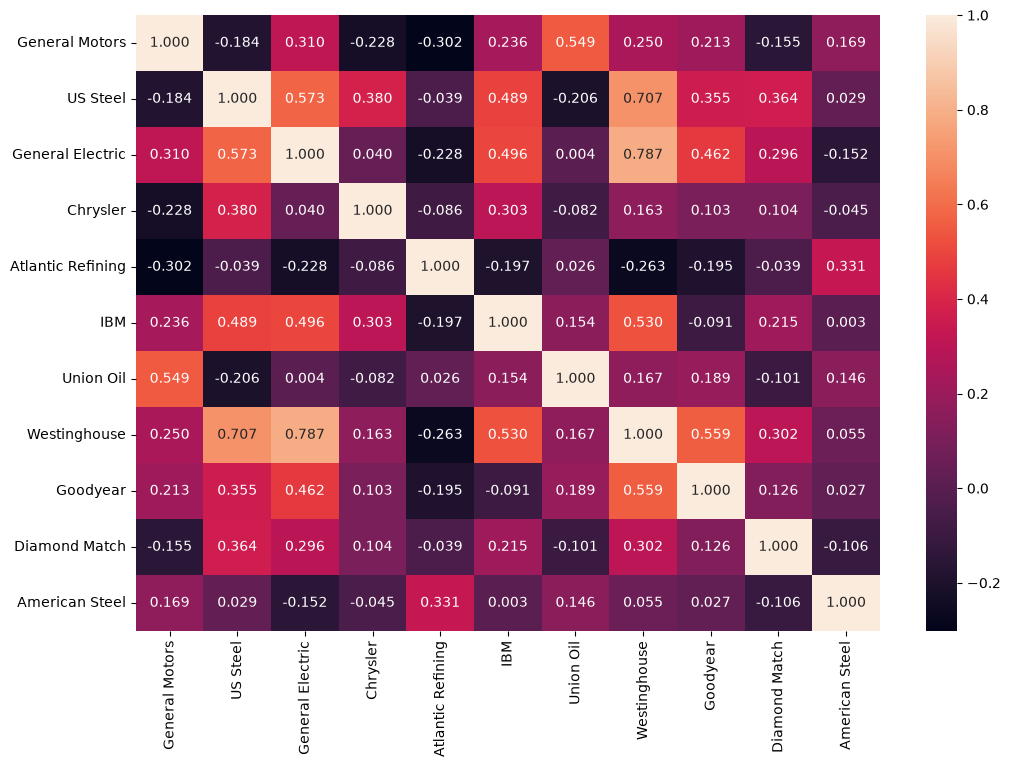

In [7]:
Sigma = np.mean(sim_param_sur['Covariance'], axis=0).reshape((n, n))
D = np.diag(np.sqrt(np.diag(Sigma)))
fig = plt.figure(num=1, figsize=(12, 8), facecolor='w')
heatmap(la.inv(D) @ Sigma @ la.inv(D), annot=True, fmt="5.3f", xticklabels=firm_name, yticklabels=firm_name)
plt.show()